In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import importlib

# Add code directory to path
sys.path.insert(0, r'C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\code')

# Force reload to get latest changes
if 'DiffLenExt' in sys.modules:
    importlib.reload(sys.modules['DiffLenExt'])
if 'perpendicular' in sys.modules:
    importlib.reload(sys.modules['perpendicular'])

from DiffLenExt import DiffusionLengthExtractor
from perpendicular import gradient_with_window

print("Imports successful!")


Imports successful!


In [2]:
data2kV = Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots_kV_unzoomed_25B\25b2_P4_2KV_125kx_30um_Vb0")
data3kV = Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots_kV_unzoomed_25B\25B2_P4_125kx_30um_Vb0")
vb_input = "02,03,04,05,06,07,08"
profile_input = "1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17"
# -------------------------------------------

# Parse VB tokens into filename substrings (case-insensitive)
vb_tokens = [t.strip() for t in vb_input.split(',') if t.strip()]
vb_patterns = []
for t in vb_tokens:
    tt = t.lower()
    if tt in ('0', 'novb', 'no', 'n'):
        vb_patterns.append('novb')
    elif tt.startswith('vb'):
        num = tt[2:]
        vb_patterns.append('vb' + num)
        vb_patterns.append('vb' + num.zfill(2))
    else:
        vb_patterns.append('vb' + tt)
        vb_patterns.append('vb' + tt.zfill(2))

# Parse profile numbers into filename substrings
profile_tokens = [p.strip() for p in profile_input.split(',') if p.strip()]
profile_patterns = []
for p in profile_tokens:
    try:
        n = int(p)
        profile_patterns.append(f"profile_{n:02d}")
    except ValueError:
        profile_patterns.append(p.lower())

# Process both directories
csv_files_2kV = []
csv_files_3kV = []

for data_dir, csv_list in [(data2kV, csv_files_2kV), (data3kV, csv_files_3kV)]:
    all_csv = sorted(list(data_dir.glob('*.csv')))
    for f in all_csv:
        name_l = f.name.lower()
        if any(v in name_l for v in vb_patterns) and any(p in name_l for p in profile_patterns):
            csv_list.append(f)

print(f"Found {len(csv_files_2kV)} CSV files in 2kV directory")
for f in csv_files_2kV:
    print(f"  {f.name}")

print(f"\nFound {len(csv_files_3kV)} CSV files in 3kV directory")
for f in csv_files_3kV:
    print(f"  {f.name}")

Found 63 CSV files in 2kV directory
  25b2_P4_2KV_125kx_30um_Vb02_profile_01.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_02.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_03.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_04.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_05.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_06.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_07.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_08.csv
  25b2_P4_2KV_125kx_30um_Vb02_profile_09.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_01.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_02.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_03.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_04.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_05.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_06.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_07.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_08.csv
  25b2_P4_2KV_125kx_30um_Vb03_profile_09.csv
  25b2_P4_2KV_125kx_30um_Vb04_profile_01.csv
  25b2_P4_2KV_125kx_30um_Vb04_profile_02.csv
  25b2_P4_2KV_125kx_30um_Vb04_profile_03.csv
  25b2_P4_2KV_125kx

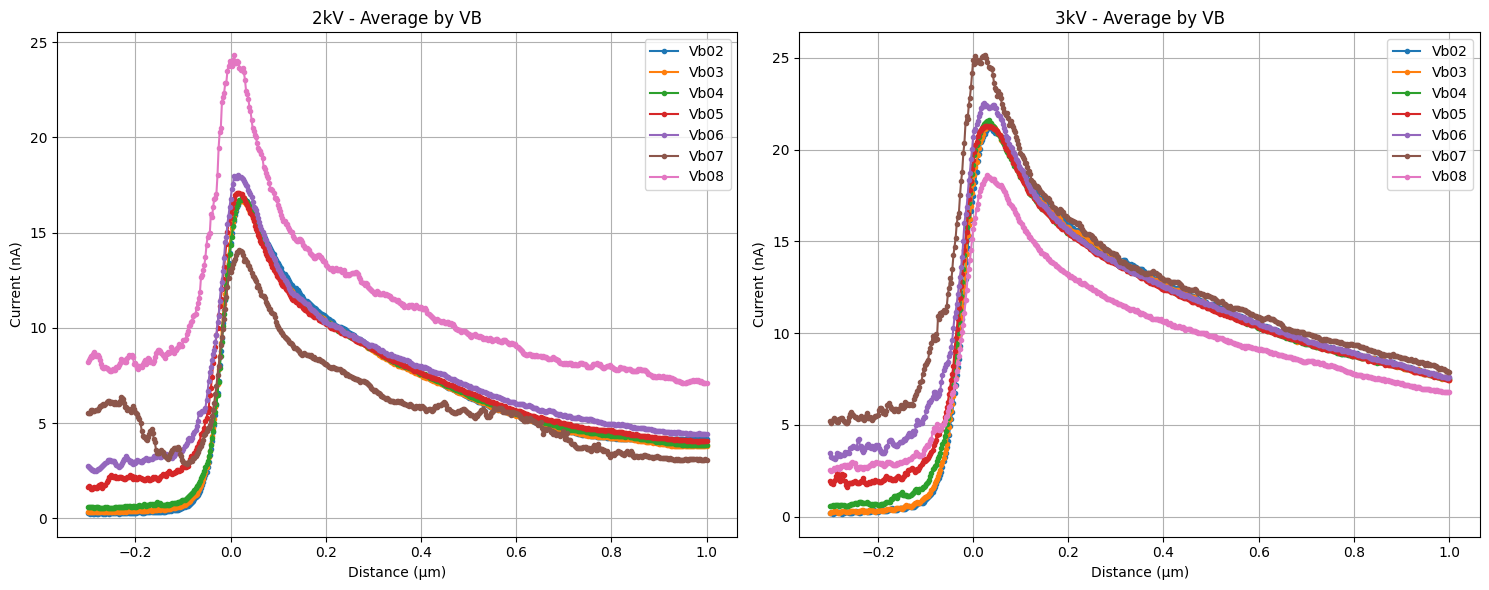

2kV - Found 7 different VB values: ['02', '03', '04', '05', '06', '07', '08']
3kV - Found 7 different VB values: ['02', '03', '04', '05', '06', '07', '08']


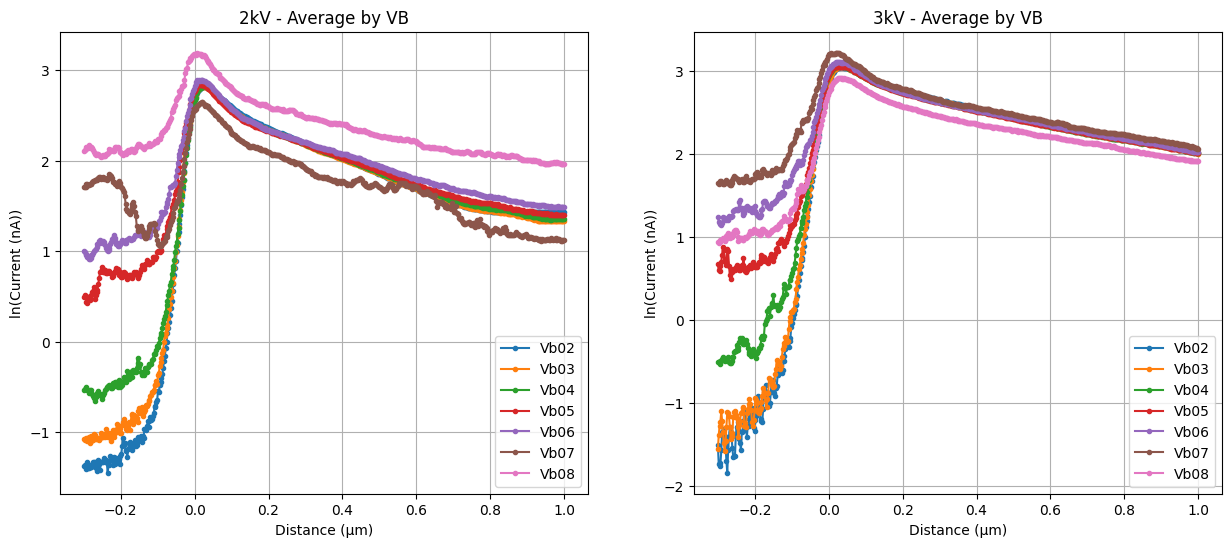

In [3]:
import re

# Process and average data for each VB value in both directories

# Dictionary to store data grouped by VB value for each directory
data_2kV_by_vb = {}
data_3kV_by_vb = {}

# Process 2kV files
for csv_file in csv_files_2kV:
    # Extract VB number from filename
    match = re.search(r'[Vv]b(\d+)', csv_file.name)
    if match:
        vb_num = match.group(1)
        df = pd.read_csv(csv_file)
        
        if vb_num not in data_2kV_by_vb:
            data_2kV_by_vb[vb_num] = []
        data_2kV_by_vb[vb_num].append(df)

# Process 3kV files
for csv_file in csv_files_3kV:
    # Extract VB number from filename
    match = re.search(r'[Vv]b(\d+)', csv_file.name)
    if match:
        vb_num = match.group(1)
        df = pd.read_csv(csv_file)
        
        if vb_num not in data_3kV_by_vb:
            data_3kV_by_vb[vb_num] = []
        data_3kV_by_vb[vb_num].append(df)

# Calculate averages and plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 2kV data
for vb_num in sorted(data_2kV_by_vb.keys()):
    dfs = data_2kV_by_vb[vb_num]
    # Select only numeric columns for averaging
    numeric_cols = dfs[0].select_dtypes(include=[np.number]).columns
    avg_df = pd.concat([df[numeric_cols] for df in dfs]).groupby(level=0).mean()
    ax1.plot(avg_df['distance_um'], avg_df['current_nA'], label=f'Vb{vb_num}', marker='.')

ax1.set_xlabel('Distance (µm)')
ax1.set_ylabel('Current (nA)')
ax1.set_title('2kV - Average by VB')
ax1.legend()
ax1.grid(True)

# Plot 3kV data
for vb_num in sorted(data_3kV_by_vb.keys()):
    dfs = data_3kV_by_vb[vb_num]
    numeric_cols = dfs[0].select_dtypes(include=[np.number]).columns
    avg_df = pd.concat([df[numeric_cols] for df in dfs]).groupby(level=0).mean()
    ax2.plot(avg_df['distance_um'], avg_df['current_nA'], label=f'Vb{vb_num}', marker='.')

ax2.set_xlabel('Distance (µm)')
ax2.set_ylabel('Current (nA)')
ax2.set_title('3kV - Average by VB')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"2kV - Found {len(data_2kV_by_vb)} different VB values: {sorted(data_2kV_by_vb.keys())}")
print(f"3kV - Found {len(data_3kV_by_vb)} different VB values: {sorted(data_3kV_by_vb.keys())}")
# Calculate averages and plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot 2kV data
for vb_num in sorted(data_2kV_by_vb.keys()):
    dfs = data_2kV_by_vb[vb_num]
    # Select only numeric columns for averaging
    numeric_cols = dfs[0].select_dtypes(include=[np.number]).columns
    avg_df = pd.concat([df[numeric_cols] for df in dfs]).groupby(level=0).mean()
    ax1.plot(avg_df['distance_um'], np.log(avg_df['current_nA']), label=f'Vb{vb_num}', marker='.')

ax1.set_xlabel('Distance (µm)')
ax1.set_ylabel('ln(Current (nA))')
ax1.set_title('2kV - Average by VB')
ax1.legend()
ax1.grid(True)

# Plot 3kV data
for vb_num in sorted(data_3kV_by_vb.keys()):
    dfs = data_3kV_by_vb[vb_num]
    numeric_cols = dfs[0].select_dtypes(include=[np.number]).columns
    avg_df = pd.concat([df[numeric_cols] for df in dfs]).groupby(level=0).mean()
    ax2.plot(avg_df['distance_um'], np.log(avg_df['current_nA']), label=f'Vb{vb_num}', marker='.')

ax2.set_xlabel('Distance (µm)')
ax2.set_ylabel('ln(Current (nA))')
ax2.set_title('3kV - Average by VB')
ax2.legend()
ax2.grid(True)

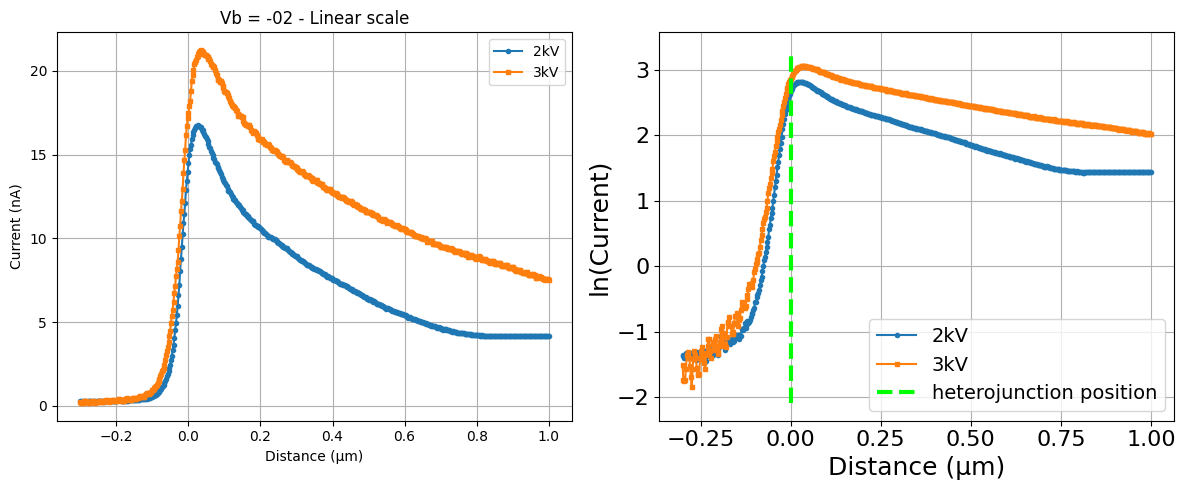

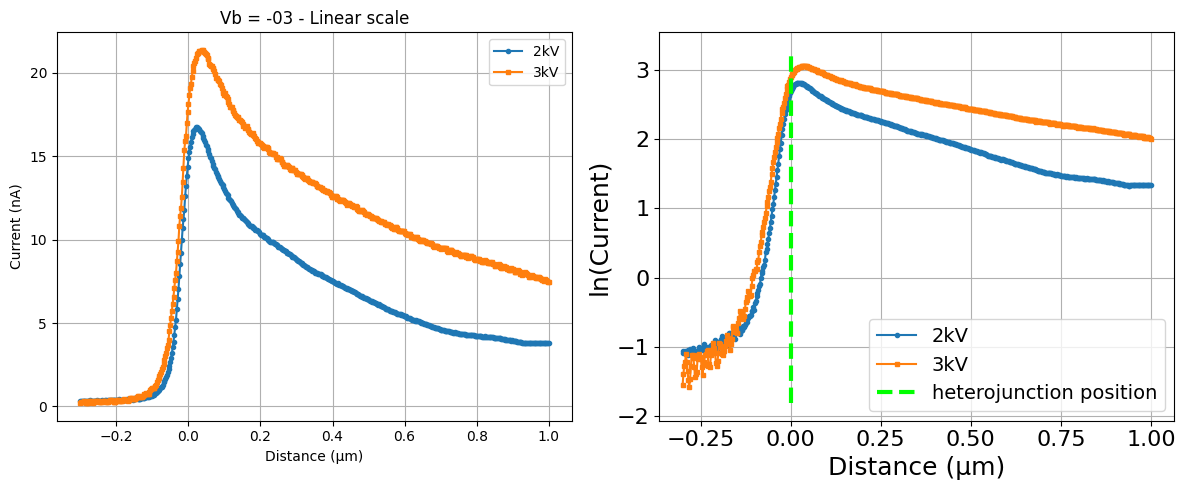

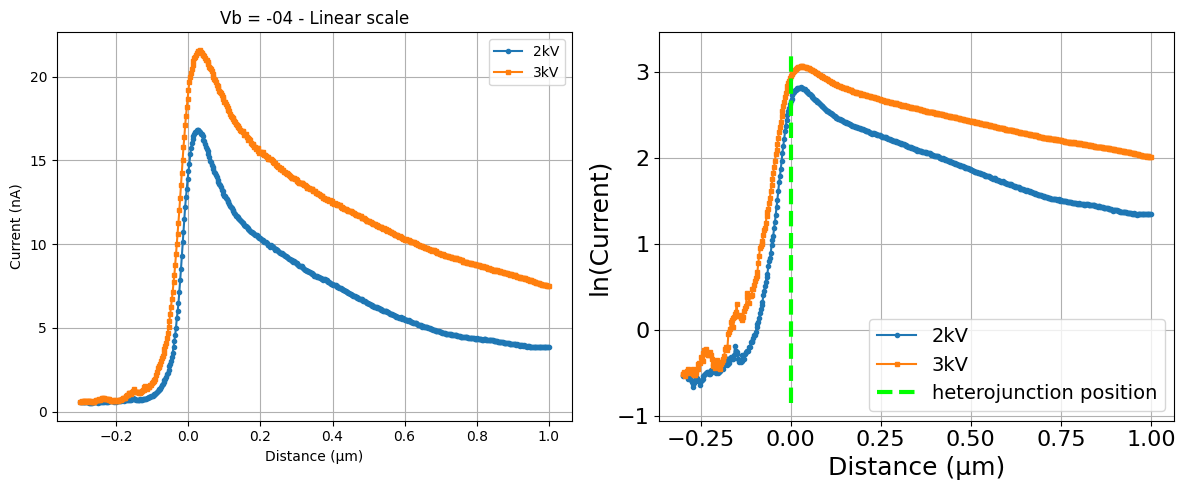

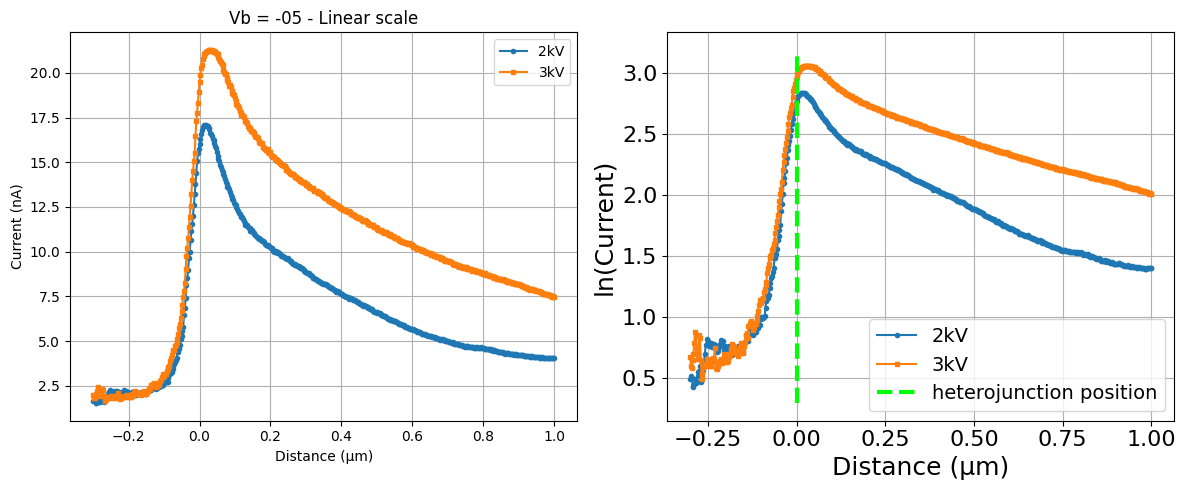

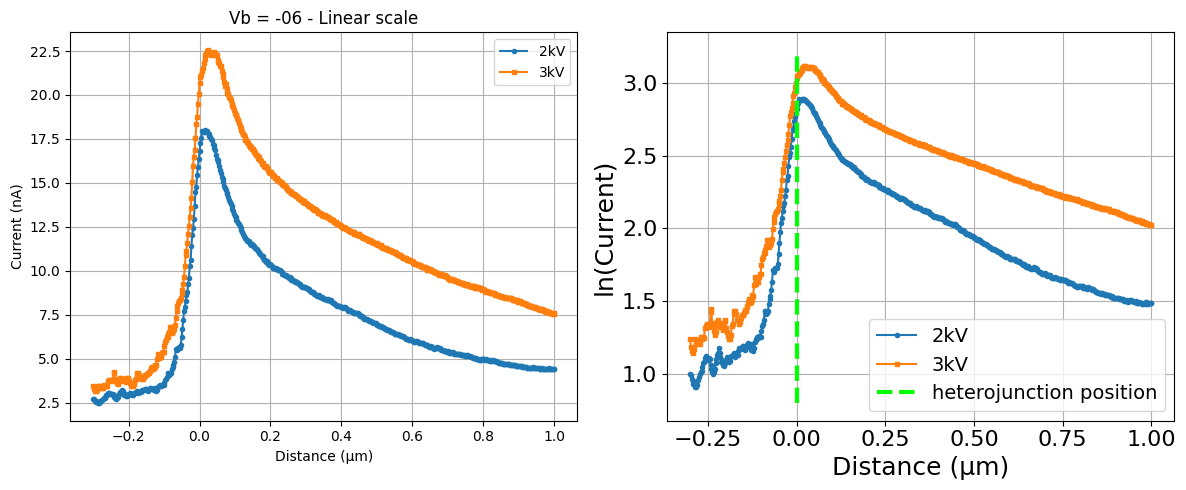

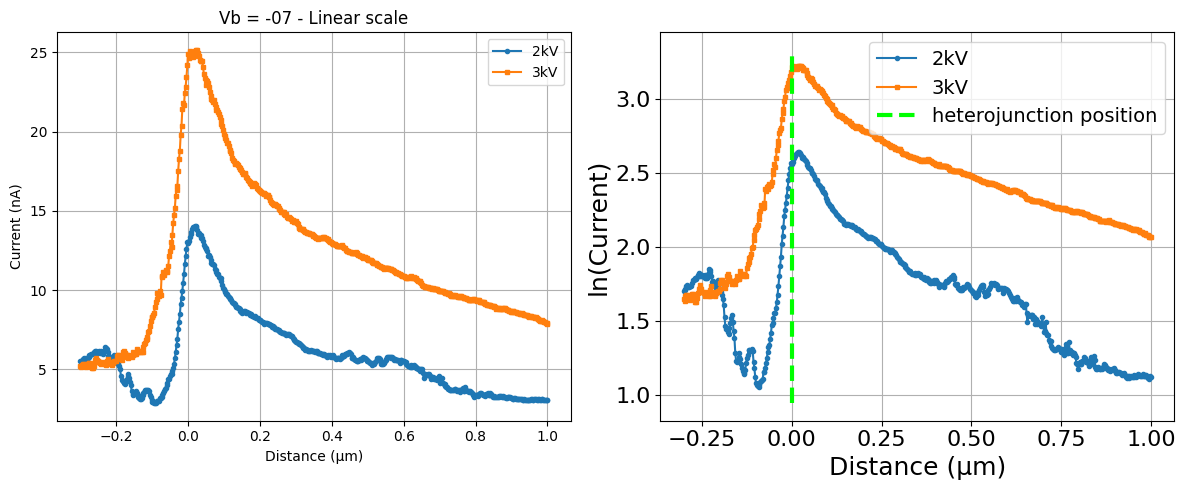

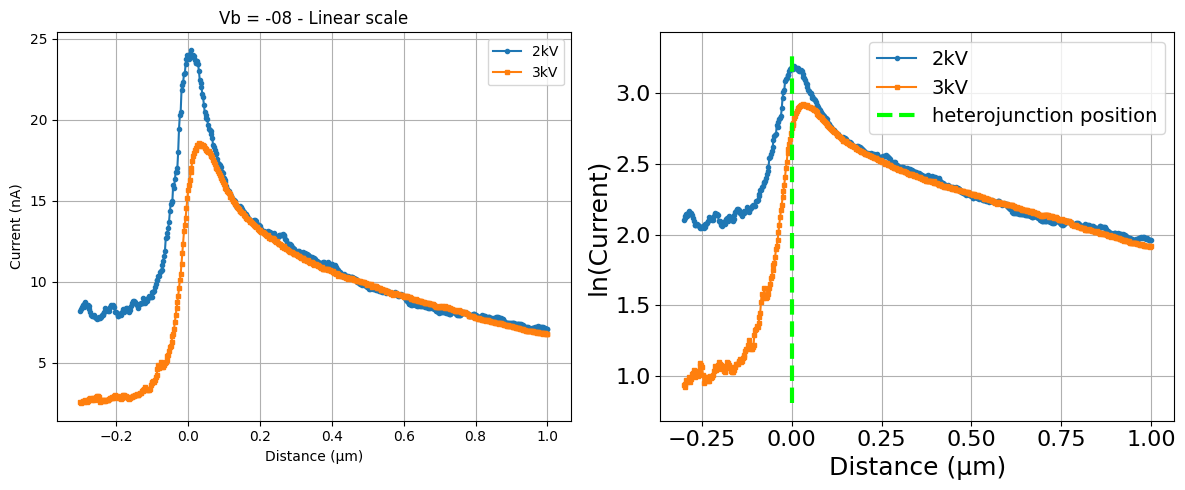

In [4]:
# Create individual plots for each VB value comparing 2kV and 3kV
vb_values = sorted(set(data_2kV_by_vb.keys()) & set(data_3kV_by_vb.keys()))

for vb_num in vb_values:
    # Average 2kV data
    dfs_2kV = data_2kV_by_vb[vb_num]
    numeric_cols = dfs_2kV[0].select_dtypes(include=[np.number]).columns
    avg_2kV = pd.concat([df[numeric_cols] for df in dfs_2kV]).groupby(level=0).mean()
    
    # Average 3kV data
    dfs_3kV = data_3kV_by_vb[vb_num]
    avg_3kV = pd.concat([df[numeric_cols] for df in dfs_3kV]).groupby(level=0).mean()
    
    # Create figure with 2 subplots (linear and log)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot linear current
    ax1.plot(avg_2kV['distance_um'], avg_2kV['current_nA'], label='2kV', marker='o', markersize=3)
    ax1.plot(avg_3kV['distance_um'], avg_3kV['current_nA'], label='3kV', marker='s', markersize=3)
    ax1.set_xlabel('Distance (µm)')
    ax1.set_ylabel('Current (nA)')
    ax1.set_title(f'Vb = -{vb_num} - Linear scale')
    ax1.legend()
    ax1.grid(True)
    
    # Plot log current
    ax2.plot(avg_2kV['distance_um'], np.log(avg_2kV['current_nA']), label='2kV', marker='o', markersize=3)
    ax2.plot(avg_3kV['distance_um'], np.log(avg_3kV['current_nA']), label='3kV', marker='s', markersize=3)
    ax2.set_xlabel('Distance (µm)', fontsize = 18)
    ax2.set_ylabel('ln(Current)',fontsize = 18)
    ax2.tick_params(axis='both', labelsize=16)
    ax2.vlines(0, ymin=ax2.get_ylim()[0], ymax=ax2.get_ylim()[1], colors='lime', linestyles='dashed', linewidth=3, label='heterojunction position')
    # ax2.set_title(f'Vb = -{vb_num} - Log scale')
    ax2.legend(fontsize = 14)
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


In [5]:
# Define two new data directories
data_new1 = Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots\folder1")
data_new2 = Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots\folder2")

# Process both new directories
csv_files_new1 = []
csv_files_new2 = []

for data_dir, csv_list in [(data_new1, csv_files_new1), (data_new2, csv_files_new2)]:
    all_csv = sorted(list(data_dir.glob('*.csv')))
    for f in all_csv:
        name_l = f.name.lower()
        if any(v in name_l for v in vb_patterns) and any(p in name_l for p in profile_patterns):
            csv_list.append(f)

print(f"Found {len(csv_files_new1)} CSV files in new directory 1")
for f in csv_files_new1:
    print(f"  {f.name}")

print(f"\nFound {len(csv_files_new2)} CSV files in new directory 2")
for f in csv_files_new2:
    print(f"  {f.name}")

# Dictionary to store data grouped by VB value for each new directory
data_new1_by_vb = {}
data_new2_by_vb = {}

# Process new directory 1 files
for csv_file in csv_files_new1:
    match = re.search(r'[Vv]b(\d+)', csv_file.name)
    if match:
        vb_num = match.group(1)
        df = pd.read_csv(csv_file)
        
        if vb_num not in data_new1_by_vb:
            data_new1_by_vb[vb_num] = []
        data_new1_by_vb[vb_num].append(df)

# Process new directory 2 files
for csv_file in csv_files_new2:
    match = re.search(r'[Vv]b(\d+)', csv_file.name)
    if match:
        vb_num = match.group(1)
        df = pd.read_csv(csv_file)
        
        if vb_num not in data_new2_by_vb:
            data_new2_by_vb[vb_num] = []
        data_new2_by_vb[vb_num].append(df)

# Create individual plots for each VB value comparing the two new directories
vb_values_new = sorted(set(data_new1_by_vb.keys()) & set(data_new2_by_vb.keys()))

for vb_num in vb_values_new:
    # Average new1 data
    dfs_new1 = data_new1_by_vb[vb_num]
    numeric_cols = dfs_new1[0].select_dtypes(include=[np.number]).columns
    avg_new1 = pd.concat([df[numeric_cols] for df in dfs_new1]).groupby(level=0).mean()
    
    # Average new2 data
    dfs_new2 = data_new2_by_vb[vb_num]
    avg_new2 = pd.concat([df[numeric_cols] for df in dfs_new2]).groupby(level=0).mean()
    
    # Create figure with 2 subplots (linear and log)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot linear current
    ax1.plot(avg_new1['distance_um'], avg_new1['current_nA'], label='Folder 1', marker='o', markersize=3)
    ax1.plot(avg_new2['distance_um'], avg_new2['current_nA'], label='Folder 2', marker='s', markersize=3)
    ax1.set_xlabel('Distance (µm)')
    ax1.set_ylabel('Current (nA)')
    ax1.set_title(f'Vb{vb_num} - Linear scale')
    ax1.legend()
    ax1.grid(True)
    
    # Plot log current
    ax2.plot(avg_new1['distance_um'], np.log(avg_new1['current_nA']), label='Folder 1', marker='o', markersize=3)
    ax2.plot(avg_new2['distance_um'], np.log(avg_new2['current_nA']), label='Folder 2', marker='s', markersize=3)
    ax2.set_xlabel('Distance (µm)')
    ax2.set_ylabel('ln(Current)')
    ax2.set_title(f'Vb{vb_num} - Log scale')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

print(f"\nFolder 1 - Found {len(data_new1_by_vb)} different VB values: {sorted(data_new1_by_vb.keys())}")
print(f"Folder 2 - Found {len(data_new2_by_vb)} different VB values: {sorted(data_new2_by_vb.keys())}")

Found 0 CSV files in new directory 1

Found 0 CSV files in new directory 2

Folder 1 - Found 0 different VB values: []
Folder 2 - Found 0 different VB values: []


In [6]:
# Extract and merge all *_avg_summary.csv files from subdirectories

# List to store all dataframes
all_summary_dfs = []

# Search through all subdirectories for *_avg_summary.csv files
# Define parent directories to search
parent_dirs = [
    Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots_kV_unzoomed_25B"),
    Path(r"C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots_kV_25B")
]

for parent_dir in parent_dirs:
    if parent_dir.exists():
        # Use rglob to recursively find all matching CSV files
        for summary_file in parent_dir.rglob('*_avg_summary.csv'):
            # Read the CSV file
            temp_df = pd.read_csv(summary_file)
            # Add a column with the filename (without extension)
            temp_df['source_file'] = summary_file.stem
            # Add a column with the parent_dir name for context
            temp_df['parent_folder'] = parent_dir.name
            # Append to list
            all_summary_dfs.append(temp_df)
            print(f"Loaded: {summary_file.name} from {parent_dir.name}")

# Merge all dataframes
if all_summary_dfs:
    merged_summary_df = pd.concat(all_summary_dfs, ignore_index=True)
    print(f"\nTotal rows in merged dataframe: {len(merged_summary_df)}")
    print(f"Number of unique source files: {merged_summary_df['source_file'].nunique()}")
    print(f"\nColumns: {list(merged_summary_df.columns)}")
    print(f"\nFirst few rows:")
    print(merged_summary_df.head())
else:
    print("No *_avg_summary.csv files found!")
    merged_summary_df = pd.DataFrame()

Loaded: 25b2_P4_125kx_30um_Vb0_avg_summary.csv from perpendicular_plots_kV_unzoomed_25B
Loaded: 25b2_P4_2KV_125kx_30um_Vb0_avg_summary.csv from perpendicular_plots_kV_unzoomed_25B
Loaded: 25b2_P4_125kx_30um_Vb0_avg_summary.csv from perpendicular_plots_kV_25B
Loaded: 25b2_P4_2KV_125kx_30um_Vb0_avg_summary.csv from perpendicular_plots_kV_25B

Total rows in merged dataframe: 28
Number of unique source files: 2

Columns: ['VB', 'Depletion (µm)', 'Lp (µm)', 'Ln (µm)', 'Left slope', 'Right slope', 'n_profiles', 'source_file', 'parent_folder']

First few rows:
     VB  Depletion (µm)   Lp (µm)   Ln (µm)  Left slope  Right slope  \
0  vb02        0.320959  0.029167  1.020399   34.285623     0.980009   
1  vb03        0.286323  0.030662  1.041508   32.613887     0.960147   
2  vb04        0.240142  0.035124  1.030798   28.470807     0.970122   
3  vb05        0.364831  0.040536  1.096516   24.669305     0.911980   
4  vb06        0.258615  0.055133  1.112754   18.138087     0.898671   

   n_pr

In [7]:
merged_summary_df["source_file"].unique()

array(['25b2_P4_125kx_30um_Vb0_avg_summary',
       '25b2_P4_2KV_125kx_30um_Vb0_avg_summary'], dtype=object)

In [8]:
merged_summary_df["parent_folder"].unique()

array(['perpendicular_plots_kV_unzoomed_25B',
       'perpendicular_plots_kV_25B'], dtype=object)

In [9]:
# Add keV column based on parent_folder name
merged_summary_df['keV'] = merged_summary_df['source_file'].apply(
    lambda x: 2 if '2KV' in x.upper() else 3
)
merged_summary_df['VB'] = merged_summary_df['VB'].str.replace('vb', '').astype(int) / 10
# Add zoom/unzoom column based on parent_folder name
merged_summary_df['zoom'] = merged_summary_df['parent_folder'].apply(
    lambda x: 'unzoomed' if 'unzoomed' in x.lower() else 'zoomed'
)
# Convert Ln and Lp from µm to nm
merged_summary_df['Ln (nm)'] = merged_summary_df['Ln (µm)'] * 1000
merged_summary_df['Lp (nm)'] = merged_summary_df['Lp (µm)'] * 1000

In [10]:
merged_summary_df.head()
merged_summary_df["zoom"].unique()

array(['unzoomed', 'zoomed'], dtype=object)

In [19]:
# Filter options for plotting
plot_kev = [2, 3]  # Which keV to plot: [2], [3], or [2, 3]
plot_zoom = ['unzoomed', 'zoomed']  # Which zoom to plot: ['unzoomed'], ['zoomed'], or ['unzoomed', 'zoomed']
plot_vb_range = (0.2,0.6)  # None for all, or tuple like (0.2, 0.8) for specific range

# Apply filters
filtered_df = merged_summary_df.copy()
filtered_df = filtered_df[filtered_df['keV'].isin(plot_kev)]
filtered_df = filtered_df[filtered_df['zoom'].isin(plot_zoom)]

if plot_vb_range is not None:
    filtered_df = filtered_df[(filtered_df['VB'] >= plot_vb_range[0]) & 
                               (filtered_df['VB'] <= plot_vb_range[1])]

print(f"Filtered data contains {len(filtered_df)} rows")
print(f"keV values: {sorted(filtered_df['keV'].unique())}")
print(f"Zoom values: {sorted(filtered_df['zoom'].unique())}")
print(f"VB range: {filtered_df['VB'].min():.2f} - {filtered_df['VB'].max():.2f} V")

Filtered data contains 20 rows
keV values: [np.int64(2), np.int64(3)]
Zoom values: ['unzoomed', 'zoomed']
VB range: 0.20 - 0.60 V


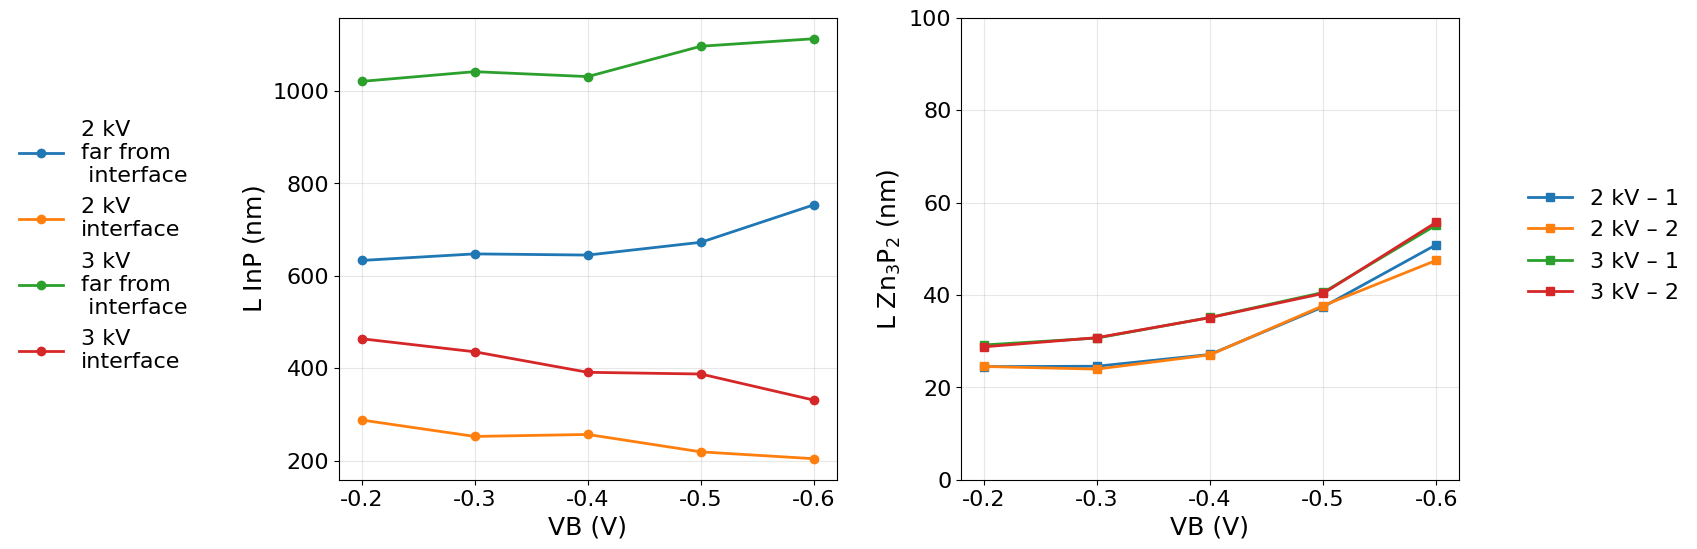

In [50]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

# -----------------------------
# Filter data for this plot
# -----------------------------
plot_kev = [2, 3]
plot_zoom = ['unzoomed', 'zoomed']
plot_vb_range = (0.2, 0.6)

filtered_df = merged_summary_df.copy()
filtered_df = filtered_df[filtered_df['keV'].isin(plot_kev)]
filtered_df = filtered_df[filtered_df['zoom'].isin(plot_zoom)]

if plot_vb_range is not None:
    filtered_df = filtered_df[
        (filtered_df['VB'] >= plot_vb_range[0]) &
        (filtered_df['VB'] <= plot_vb_range[1])
    ]

# -----------------------------
# Create figure
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# -----------------------------
# Plot data
# -----------------------------
for kev in sorted(filtered_df['keV'].unique()):
    for zoom in sorted(filtered_df['zoom'].unique()):

        subset = filtered_df[
            (filtered_df['keV'] == kev) &
            (filtered_df['zoom'] == zoom)
        ].sort_values('VB')

        if subset.empty:
            continue

        # --- Labels ---
        zoom_label_long = 'far from \n interface' if zoom == 'unzoomed' else 'interface'
        label_ln = f"{kev} kV\n{zoom_label_long}"

        zoom_label_short = '1' if zoom == 'unzoomed' else '2'
        label_lp = f"{kev} kV – {zoom_label_short}"

        # --- Plots ---
        ax1.plot(
            subset['VB'],
            subset['Ln (nm)'],
            marker='o',
            linewidth=2,
            label=label_ln
        )

        ax2.plot(
            subset['VB'],
            subset['Lp (nm)'],
            marker='s',
            linewidth=2,
            label=label_lp
        )

# -----------------------------
# Axes formatting
# -----------------------------
for ax in (ax1, ax2):
    ax.set_xlabel('VB (V)', fontsize=18)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=16)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"-{x:g}"))

ax1.set_ylabel(r'L $\mathrm{InP}$ (nm)', fontsize=18)
ax2.set_ylabel(r'L $\mathrm{Zn_3P_2}$ (nm)', fontsize=18)
ax2.set_ylim(0, 100)

# -----------------------------
# Reserve space for legends
# -----------------------------
fig.subplots_adjust(left=0.22, right=0.78, wspace=0.25)

# -----------------------------
# Legends outside axes
# -----------------------------
ax1.legend(
    loc='center left',
    bbox_to_anchor=(0.05, 0.5),
    bbox_transform=fig.transFigure,
    fontsize=16,
    frameon=False
)

ax2.legend(
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    bbox_transform=fig.transFigure,
    fontsize=16,
    frameon=False
)

plt.show()


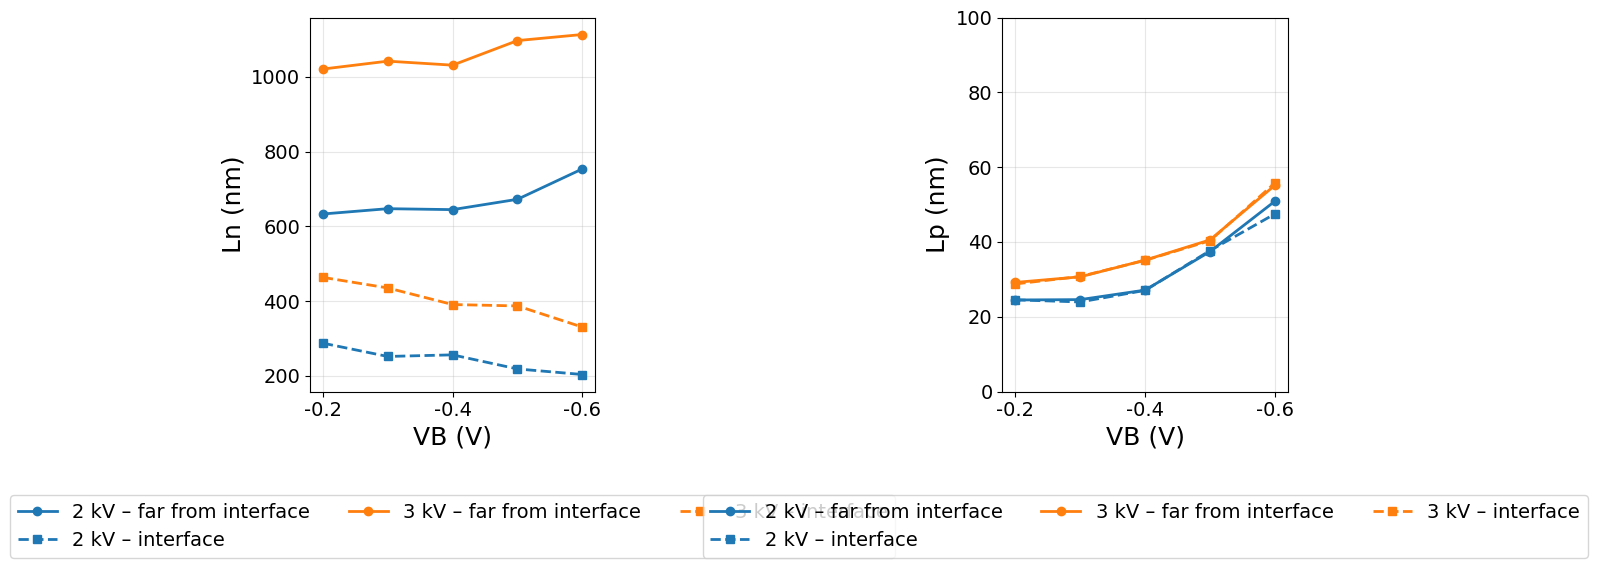

In [13]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

# -----------------------------
# Visual encodings
# -----------------------------
zoom_style = {
    'unzoomed': {'marker': 'o', 'linestyle': '-',  'label': 'far from interface'},
    'zoomed':   {'marker': 's', 'linestyle': '--', 'label': 'interface'}
}

colors = plt.cm.tab10.colors
kev_colors = {
    kev: colors[i % len(colors)]
    for i, kev in enumerate(sorted(filtered_df['keV'].unique()))
}

# -----------------------------
# Create figure
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Plot data
# -----------------------------
for kev in sorted(filtered_df['keV'].unique()):
    for zoom in sorted(filtered_df['zoom'].unique()):

        subset = filtered_df[
            (filtered_df['keV'] == kev) &
            (filtered_df['zoom'] == zoom)
        ].sort_values('VB')

        if subset.empty:
            continue

        style = zoom_style.get(zoom, {})

        label_ln = f"{kev} kV – {style.get('label', zoom)}"
        label_lp = f"{kev} kV – {style.get('label', zoom)}"

        # Ln plot
        ax1.plot(
            subset['VB'],
            subset['Ln (nm)'],
            color=kev_colors[kev],
            marker=style.get('marker', 'o'),
            linestyle=style.get('linestyle', '-'),
            linewidth=2,
            label=label_ln
        )

        # Lp plot
        ax2.plot(
            subset['VB'],
            subset['Lp (nm)'],
            color=kev_colors[kev],
            marker=style.get('marker', 's'),
            linestyle=style.get('linestyle', '--'),
            linewidth=2,
            label=label_lp
        )

# -----------------------------
# Configure Ln plot
# -----------------------------
ax1.set_xlabel('VB (V)', fontsize=18)
ax1.set_ylabel('Ln (nm)', fontsize=18)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=14)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"-{x:g}"))

ax1.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=14
)

# -----------------------------
# Configure Lp plot
# -----------------------------
ax2.set_xlabel('VB (V)', fontsize=18)
ax2.set_ylabel('Lp (nm)', fontsize=18)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=14)
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"-{x:g}"))

ax2.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=14
)

plt.tight_layout()
plt.show()


In [14]:
# Read the CSV file and assign it to a variable
extracted_df = pd.read_csv(r'C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\25B2_45-200_data.csv')
print(f"Loaded data with {len(extracted_df)} rows and {len(extracted_df.columns)} columns")
print(f"\nColumns: {list(extracted_df.columns)}")
print(f"\nFirst few rows:")
print(extracted_df.head())
extracted_df_125 = pd.read_csv(r'C:\Users\biselli\Desktop\Code\MasterThesis\EBIC_Analysis_Tool\perpendicular_plots_unzoomed\25B2_P4_125kx_30um\25b2_P4_125kx_30um_avg_summary.csv')
extracted_df_125.head()

Loaded data with 102 rows and 27 columns

Columns: ['sample_folder', 'filename', 'sample', 'type', 'zoom', 'aperture', 'vb', 'profile', 'depletion_width_um', 'left_slope', 'left_r2', 'left_Lp_um', 'left_start_um', 'right_slope', 'right_r2', 'right_Ln_um', 'right_start_um', 'T', 'ratio', 'P', 'D', 'A_ratio', 'Lp_nm', 'Ln_nm', 'depletion_width_nm', 'right_start_nm', 'left_start_nm']

First few rows:
       sample_folder                               filename sample    type  \
0  25B2_P4_80kx_30um  25B2_P4_80kx_30um_noVb_profile_01.csv   25B2  45-200   
1  25B2_P4_80kx_30um  25B2_P4_80kx_30um_noVb_profile_02.csv   25B2  45-200   
2  25B2_P4_80kx_30um  25B2_P4_80kx_30um_noVb_profile_03.csv   25B2  45-200   
3  25B2_P4_80kx_30um  25B2_P4_80kx_30um_noVb_profile_04.csv   25B2  45-200   
4  25B2_P4_80kx_30um  25B2_P4_80kx_30um_noVb_profile_05.csv   25B2  45-200   

   zoom aperture   vb  profile  depletion_width_um  left_slope  ...    T  \
0  80kx     30um  0.0        1            0.080292   3

,VB,Depletion (µm),Lp (µm),Ln (µm),Left slope,Right slope,n_profiles
0,novb,0.085435,0.027639,0.513193,36.180440,1.948584,10
1,vb02,0.087744,0.029165,0.452679,34.287690,2.209072,10
2,vb03,0.055417,0.031149,0.469418,32.103634,2.130295,10
3,vb04,0.069272,0.035564,0.396219,28.118532,2.523858,10
4,vb05,0.066963,0.041199,0.387966,24.272591,2.577544,10


In [15]:
# Convert VB column from format 'vb03' to 0.3, handling 'novb' as 0.0
extracted_df_125['VB'] = extracted_df_125['VB'].apply(
    lambda x: 0.0 if x.lower() == 'novb' else int(x.lower().replace('vb', '')) / 10
)

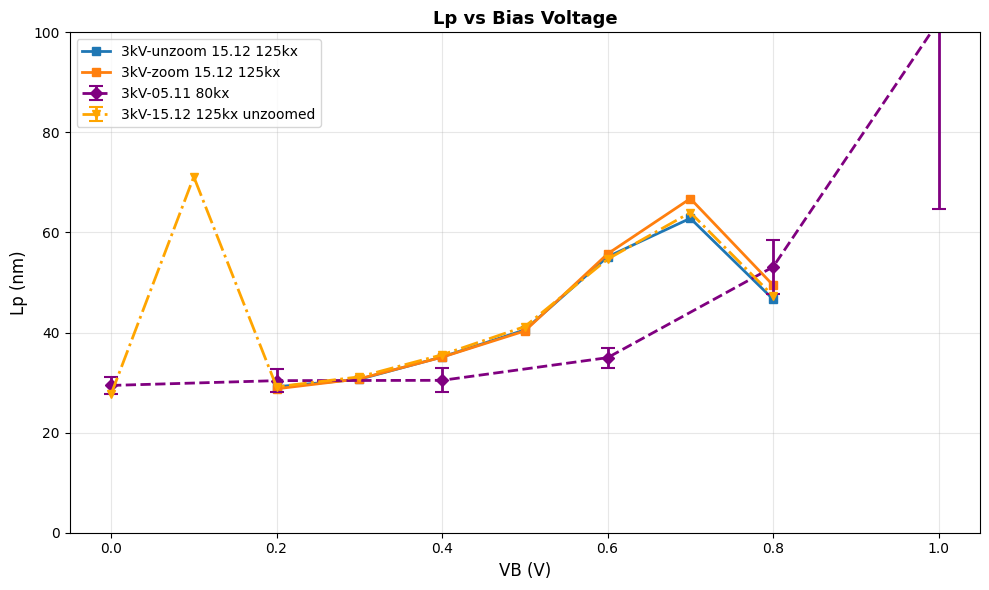

In [16]:
# Filter options for plotting
plot_kev = [3]  # Which keV to plot: [2], [3], or [2, 3]
plot_zoom = ['zoomed','unzoomed']  # Which zoom to plot: ['unzoomed'], ['zoomed'], or ['unzoomed', 'zoomed']
plot_vb_range = (None)  # None for all, or tuple like (0.2, 0.8) for specific range

# Apply filters
filtered_df = merged_summary_df.copy()
filtered_df = filtered_df[filtered_df['keV'].isin(plot_kev)]
filtered_df = filtered_df[filtered_df['zoom'].isin(plot_zoom)]

# Additional filter: exclude 2kV unzoomed
filtered_df = filtered_df[~((filtered_df['keV'] == 2) & (filtered_df['zoom'] == 'unzoomed'))]

if plot_vb_range is not None:
    filtered_df = filtered_df[(filtered_df['VB'] >= plot_vb_range[0]) & 
                               (filtered_df['VB'] <= plot_vb_range[1])]

# Plot Lp vs VB for each keV-zoom combination with extracted_df overlay for 3kV Lp
fig, ax = plt.subplots(figsize=(10, 6))

# Get unique combinations of keV and zoom from filtered data
for kev in sorted(filtered_df['keV'].unique()):
    for zoom in sorted(filtered_df['zoom'].unique()):
        # Filter data for this combination
        mask = (filtered_df['keV'] == kev) & (filtered_df['zoom'] == zoom)
        subset = filtered_df[mask].sort_values('VB')
        
        if len(subset) > 0:
            # Create labels for Lp plot
            zoom_label_lp = 'unzoom 15.12 125kx' if zoom == 'unzoomed' else 'zoom 15.12 125kx'
            label_lp = f'{kev}kV-{zoom_label_lp}'
            
            # Plot Lp
            ax.plot(subset['VB'], subset['Lp (nm)'], marker='s', label=label_lp, linewidth=2)

# Add extracted_df data for 3kV Lp (only for zoomed/interface data)
# Calculate average and std for Lp from extracted_df grouped by vb
extracted_grouped = extracted_df.groupby('vb').agg({'Lp_nm': ['mean', 'std']}).reset_index()
extracted_grouped.columns = ['vb', 'Lp_mean', 'Lp_std']

# Apply VB range filter to extracted data
if plot_vb_range is not None:
    extracted_grouped = extracted_grouped[(extracted_grouped['vb'] >= plot_vb_range[0]) & 
                                          (extracted_grouped['vb'] <= plot_vb_range[1])]

# Plot average Lp from extracted_df with error bars
ax.errorbar(extracted_grouped['vb'], extracted_grouped['Lp_mean'], 
            yerr=extracted_grouped['Lp_std'],
            marker='D', linestyle='--', label='3kV-05.11 80kx', 
            linewidth=2, color='purple', capsize=5, capthick=1.5)

# Calculate average and std for Lp from extracted_df_125 grouped by VB
extracted_grouped_125 = extracted_df_125.groupby('VB').agg({'Lp (µm)': ['mean', 'std']}).reset_index()
extracted_grouped_125.columns = ['vb', 'Lp_mean', 'Lp_std']
# Convert from µm to nm
extracted_grouped_125['Lp_mean'] = extracted_grouped_125['Lp_mean'] * 1000
extracted_grouped_125['Lp_std'] = extracted_grouped_125['Lp_std'] * 1000

# Apply VB range filter to extracted_df_125 data
if plot_vb_range is not None:
    extracted_grouped_125 = extracted_grouped_125[(extracted_grouped_125['vb'] >= plot_vb_range[0]) & 
                                                   (extracted_grouped_125['vb'] <= plot_vb_range[1])]

# Plot average Lp from extracted_df_125 with error bars
ax.errorbar(extracted_grouped_125['vb'], extracted_grouped_125['Lp_mean'], 
            yerr=extracted_grouped_125['Lp_std'],
            marker='v', linestyle='-.', label='3kV-15.12 125kx unzoomed', 
            linewidth=2, color='orange', capsize=5, capthick=1.5)

# Configure Lp plot
ax.set_xlabel('VB (V)', fontsize=12)
ax.set_ylabel('Lp (nm)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_xlim()
ax.set_title('Lp vs Bias Voltage', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

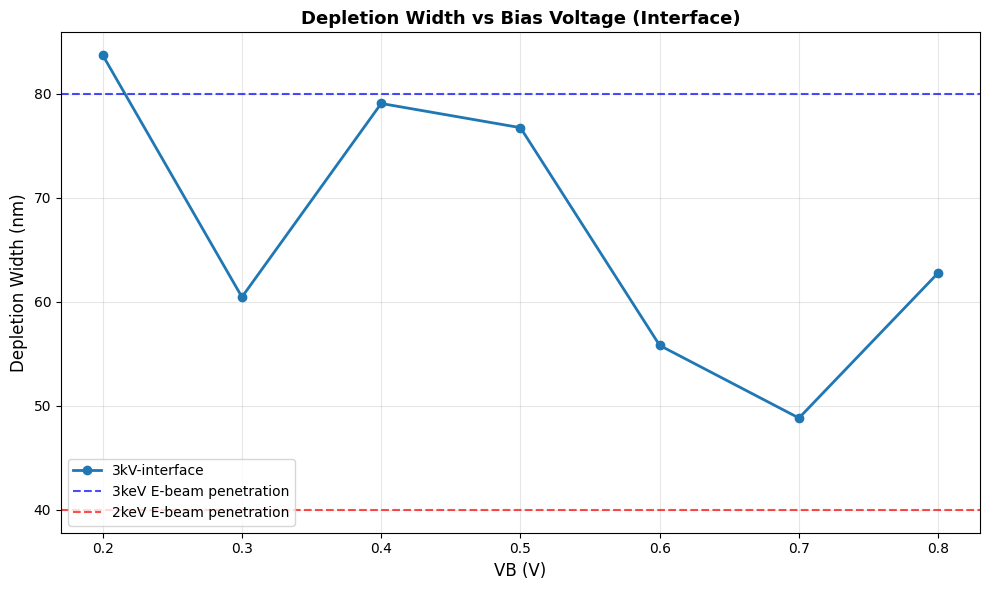

In [17]:
# Plot Depletion Width vs VB for each keV-zoom combination (interface only)
fig, ax = plt.subplots(figsize=(10, 6))

# Get unique keV values from filtered data
for kev in sorted(filtered_df['keV'].unique()):
    # Filter data for this keV and only zoomed (interface) data
    mask = (filtered_df['keV'] == kev) & (filtered_df['zoom'] == 'zoomed')
    subset = filtered_df[mask].sort_values('VB')
    
    if len(subset) > 0:
        # Create label
        label = f'{kev}kV-interface'
        
        # Plot Depletion Width (convert from µm to nm)
        ax.plot(subset['VB'], subset['Depletion (µm)'] * 1000, marker='o', label=label, linewidth=2)

# Add horizontal reference lines
ax.axhline(y=80, color='blue', linestyle='--', linewidth=1.5, label='3keV E-beam penetration', alpha=0.7)
ax.axhline(y=40, color='red', linestyle='--', linewidth=1.5, label='2keV E-beam penetration', alpha=0.7)

# Configure plot
ax.set_xlabel('VB (V)', fontsize=12)
ax.set_ylabel('Depletion Width (nm)', fontsize=12)
ax.set_title('Depletion Width vs Bias Voltage (Interface)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
